In [9]:
#import relevant Library
import pandas as pd

#Load the dataset
df = pd.read_csv("diabetic_data.csv")

#Display first five rows
print("First five rows")
display(df.head())

#Display  the structure of the dataset
print("\nDatasetstructure:")
df.info()

#Display the list of columns
print("\nColumn names:")
print(df.columns)

#Number of rows and columns
rows, cols = df.shape
print(f"\nNumber of rows: {rows}")
print(f"\nNumber of columns: {cols}")


C:\Users\smdladlamba\AppData\Local\Temp\ipykernel_22660\1508739955.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("diabetic_data.csv")


First five rows


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Datasetstructure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-nul

# Identified data-quality issues

* The admission_type_id variable consists of numeric codes that are difficult to interpret and would not be suitable for visualisation.
* The dataset consisted of missing values denoted as question marks, which is inappropriate for analysis.
* There were "unknown/Invalid" entries under the Gender category, this causes a discrepancy in the data and will distort comparison between Males and Females.
* The num_medications and time_in_hospital data types were incorrect.
* There is no variable for the number of encounters that each patient has had, which is key information.
* The age data is split into many small, narrow groups which makes the data very granular, it will cause clutter when we attempt to visualise and will make trends difficut to interpret.

In [15]:
#replace "?" with NaN
df.replace('?', pd.NA, inplace=True)

#check for missing values
print("check missing values")
df[['race', 'medical_specialty']].isna().sum()

race                  2273
medical_specialty    49949
dtype: int64

In [ ]:
The data had missing values which where denoted by "?", All occurences of "?" were replaced by null values and handled more appropriately.

In [16]:
#select only variables needed for visualisation
df = df[
    [
        'patient_nbr', 'readmitted', 'admission_type_id',
        'medical_specialty', 'num_medications',
        'time_in_hospital', 'age', 'gender', 'race'
    ]
]

# Clean Categorial values

In [17]:
# Convert readmitted into clearer categories
df['readmitted'] = df['readmitted'].replace({
    '<30': 'Within 30 days',
    '>30': 'After 30 days',
    'NO': 'No readmission'
})

In [ ]:
# Remove invalid gender entries
df = df[df['gender'].isin(['Male', 'Female'])]

In [ ]:
#Handle missing categorical values
df['race'] = df['race'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

# Convert Admission Type IDs to Meaningful Labels

In [12]:
# Convert Admission Type IDs to Meaningful Labels
admission_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'NULL',
    7: 'Trauma',
    8: 'Not Mapped'
}

df['admission_type'] = df['admission_type_id'].map(admission_map)

# Create a new analytical variable that shows the number of visits per patient

In [ ]:
# Count number of visits per patient
encounters = df.groupby('patient_nbr').size().reset_index(name='num_encounters')

# Merge back into main dataset
df = df.merge(encounters, on='patient_nbr', how='left')

# Conversion of Data Types to more appropriate Data Types

In [21]:
df['num_medications'] = pd.to_numeric(df['num_medications'], errors='coerce')
df['time_in_hospital'] = pd.to_numeric(df['time_in_hospital'], errors='coerce')

# Create Number of encounters per Patient

In [ ]:
encounters = df.groupby('patient_nbr').size().reset_index(name='num_encounters')

df = df.merge(encounters, on='patient_nbr', how='left')

# Reduce high Cardinality

In [20]:
# Keep top 10 specialties, group others
top_specialties = df['medical_specialty'].value_counts().nlargest(10).index

df['medical_specialty'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

In [ ]:
#Age simplification
def simplify_age(age):
    if age in ['[0-10)', '[10-20)']:
        return '0–20'
    elif age in ['[20-30)', '[30-40)']:
        return '20–40'
    elif age in ['[40-50)', '[50-60)']:
        return '40–60'
    elif age in ['[60-70)', '[70-80)']:
        return '60–80'
    else:
        return '80+'

df['age_group'] = df['age'].apply(simplify_age)


# Final Dataset Check

In [13]:
print("Cleaned dataset preview:")
display(df.head())

print("\nDataset shape after cleaning:")
print(df.shape)

print("\nColumns in cleaned dataset:")
print(df.columns.tolist())

df.info()

Cleaned dataset preview:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,NULL
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,Emergency
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,Emergency
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,Emergency
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency



Dataset shape after cleaning:
(101766, 51)

Columns in cleaned dataset:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns 

# Task 4: Visualisation Construction

**Distribution of readmission**

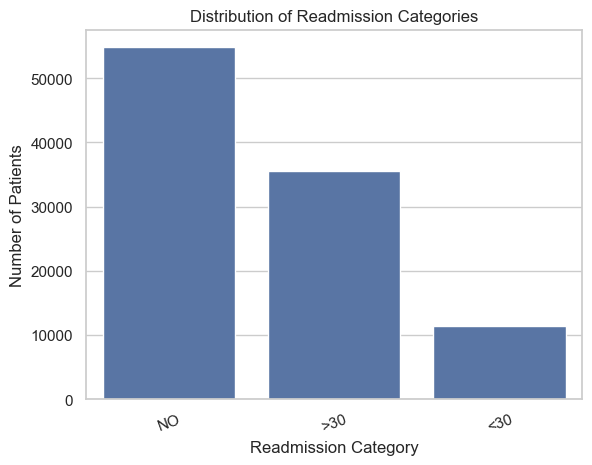

In [14]:
plt.figure()
sns.countplot(data=df, x='readmitted')
plt.title("Distribution of Readmission Categories")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.show()

**Interpretation:**
About 10% of patients are readmitted within 30 days of being discharged from a hospital stay. Readmissions are the most uncommon outcome but they are still a critical key point for healthcare analysis.

**Readmission by admission type**

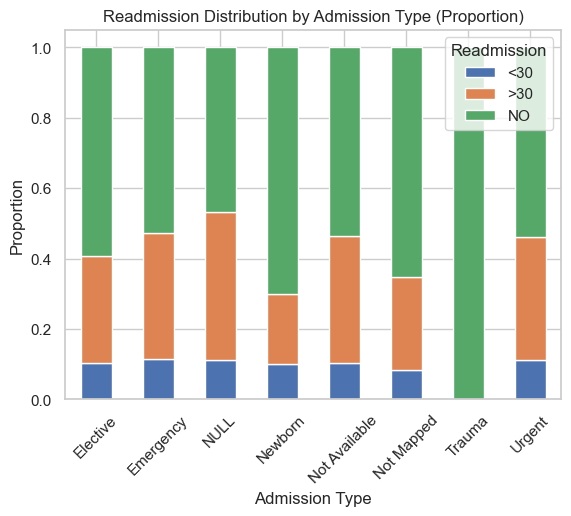

In [15]:
prop_df = pd.crosstab(df['admission_type'], df['readmitted'], normalize='index')

prop_df.plot(kind='bar', stacked=True)
plt.title("Readmission Distribution by Admission Type (Proportion)")
plt.xlabel("Admission Type")
plt.ylabel("Proportion")
plt.legend(title="Readmission")
plt.xticks(rotation=45)
plt.show()

**Readmission by Age and Gender**

       age age_group
0   [0-10)      0–20
1  [10-20)      0–20
2  [20-30)     20–40
3  [30-40)     20–40
4  [40-50)     40–60
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'chan

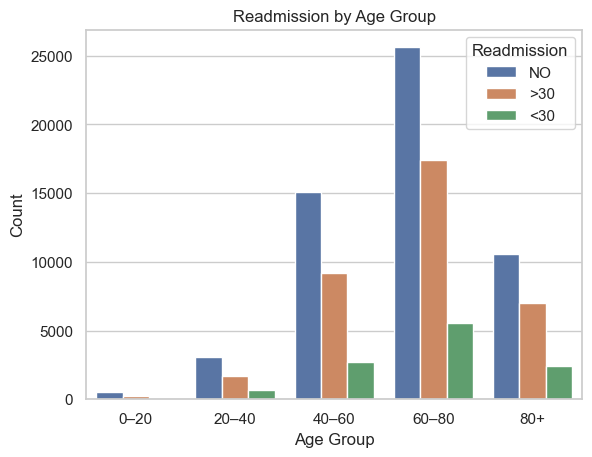

In [18]:
# Create simplified age groups
def simplify_age(age):
    if age in ['[0-10)', '[10-20)']:
        return '0–20'
    elif age in ['[20-30)', '[30-40)']:
        return '20–40'
    elif age in ['[40-50)', '[50-60)']:
        return '40–60'
    elif age in ['[60-70)', '[70-80)']:
        return '60–80'
    else:
        return '80+'

df['age_group'] = df['age'].apply(simplify_age)

# Check that it was created
print(df[['age', 'age_group']].head())
print(df.columns)
plt.figure()
sns.countplot(data=df, x='age_group', hue='readmitted')
plt.title("Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Readmission")
plt.show()

**Interpretation:**
Even though readmissions are overall lower, the biggest contributor to readmissions wthin 30 days is patients that were admitted for urgent care or in the emergency unit, which is an indication that interventions might need to be targeted towards the healthcare provided in emergency and urgent admissions.

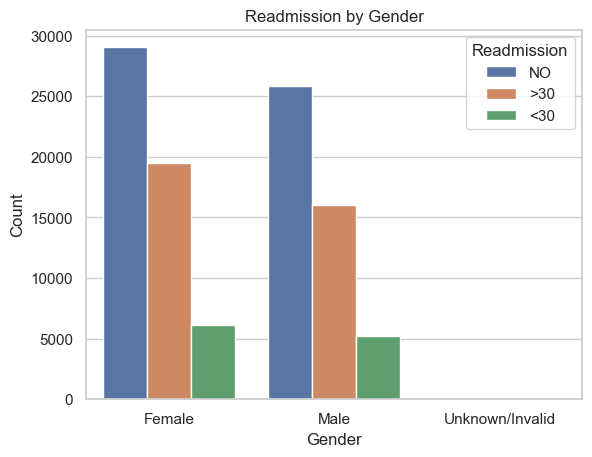

In [19]:
plt.figure()
sns.countplot(data=df, x='gender', hue='readmitted')
plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Readmission")
plt.show()

**Interpretation:**
Gender seems to have little or not effect on readmission , but we also see that readmission within 30 days is higher with older ages (we see a peak in the 60-80 Age Group) and because of that we can say age is an important factor in readmission than gender.

**Time in hospital vs Readmission**

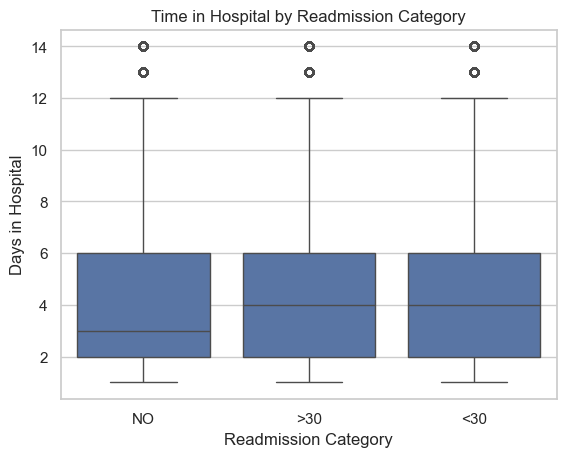

In [20]:
plt.figure()
sns.boxplot(data=df, x='readmitted', y='time_in_hospital')
plt.title("Time in Hospital by Readmission Category")
plt.xlabel("Readmission Category")
plt.ylabel("Days in Hospital")
plt.show()

**Interpretation:**
The time spent in hospital is quite similar in all 3 categories, there is a slightyly higher Median for readmitted patients which may mean that longer stays do not strongly affect readmission.

**Number of medications vs readmission**

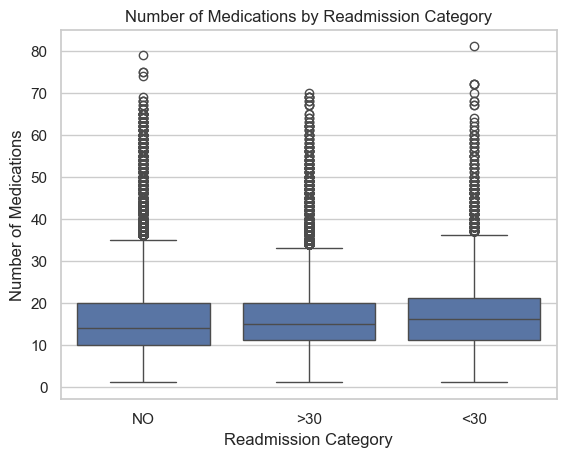

In [21]:
plt.figure()
sns.boxplot(data=df, x='readmitted', y='num_medications')
plt.title("Number of Medications by Readmission Category")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Medications")
plt.show()

**Interpretation:**
Patients that are readmitted particularly within 30 days have a slightly higher count for medications which means, medication is a contributing factor but not a strong one.

**Treatment Intensity by Race and Readmission**

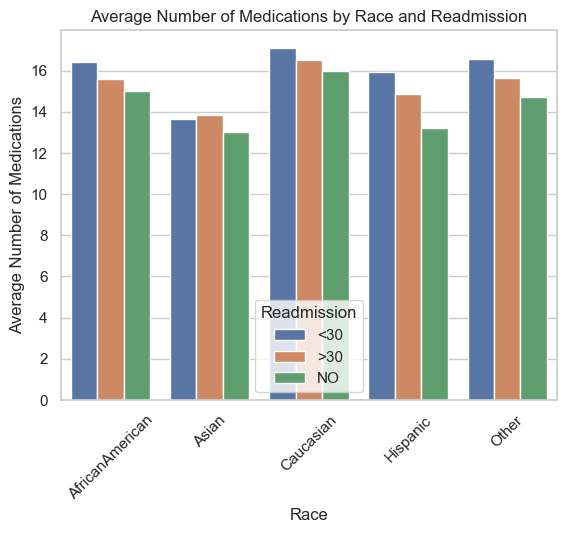

In [22]:
mean_med = df.groupby(['race', 'readmitted'])['num_medications'].mean().reset_index()

plt.figure()
sns.barplot(data=mean_med, x='race', y='num_medications', hue='readmitted')
plt.title("Average Number of Medications by Race and Readmission")
plt.xlabel("Race")
plt.ylabel("Average Number of Medications")
plt.xticks(rotation=45)
plt.legend(title="Readmission")
plt.show()

`**Interpretation:**
The number of medications taken by the patient is associated with the increase of readmission, particularly within 30 days in all races. There is different averages for medications across races but the pattern is consistent and so, clinical complications (as shown by taking more medications) is a key factor in readmissions.

**Early Readmission vs Number of Encounters**

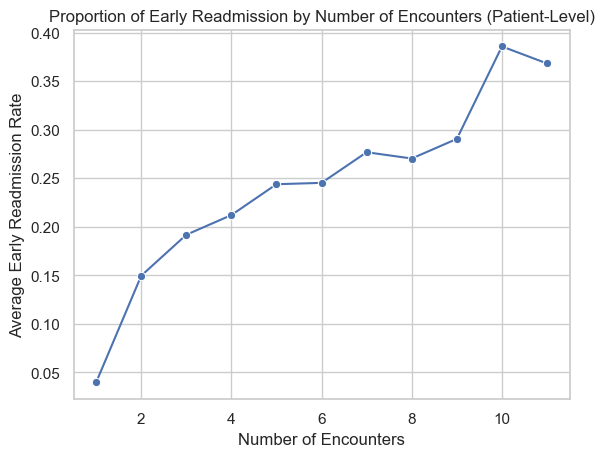

In [27]:
# Clean label (important)
df['readmitted'] = df['readmitted'].astype(str).str.strip()

# Create early readmission flag at encounter level
df['early'] = (df['readmitted'] == '<30').astype(int)

# Patient-level aggregation
patient_df = (
    df.groupby('patient_nbr')
      .agg(
          num_encounters=('encounter_id', 'count'),
          early_rate=('early', 'mean')   # proportion of encounters that are early readmissions
      )
      .reset_index()
)

# Group by number of encounters
encounter_prop = (
    patient_df.groupby('num_encounters')['early_rate']
      .mean()
      .reset_index()
)

# Optional: remove unreliable groups (very few patients)
counts = patient_df['num_encounters'].value_counts()
valid = counts[counts >= 20].index
encounter_prop = encounter_prop[encounter_prop['num_encounters'].isin(valid)]

# Plot
plt.figure()
sns.lineplot(data=encounter_prop, x='num_encounters', y='early_rate', marker='o')
plt.title("Proportion of Early Readmission by Number of Encounters (Patient-Level)")
plt.xlabel("Number of Encounters")
plt.ylabel("Average Early Readmission Rate")
plt.show()

**Interpretation:**
We see a steady increase with the number of encounters per patient which indicates that patients that have higher healthcare utilisation are at a higher risk of being readmitted within 30 days.

**Most frequent Medical specialty**

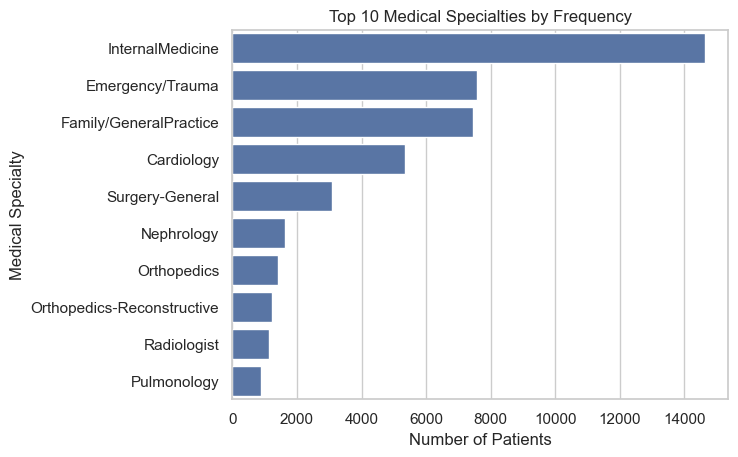

In [25]:
# Exclude unknown values
spec_df = df[df['medical_specialty'] != 'Unknown']

top_specs = spec_df['medical_specialty'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_specs.values, y=top_specs.index)
plt.title("Top 10 Medical Specialties by Frequency")
plt.xlabel("Number of Patients")
plt.ylabel("Medical Specialty")
plt.show()

**Interpretation:**
Internal Medicine contributes the most to admissions , which indicates that most patients are managed for general or complex medical conditions instead of highly specialised or surgical care.